In [25]:
import numpy as np
import scipy as scipy
import scipy.special
import matplotlib.pyplot as plt
import time
import uncertainties as error
import pandas as pd

Problem 1

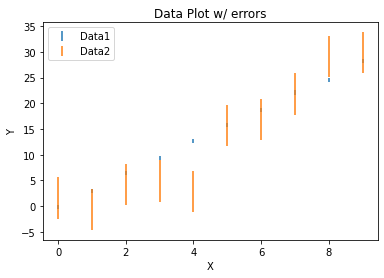

In [197]:
#This is my data input for the .txt files, may need to adjust the filepath
Data1=pd.read_csv('HW4_Data/data1.txt', names=['x', 'y', 'yerr'], delimiter=' ')
Data2=pd.read_csv('HW4_Data/data2.txt', names=['x', 'y', 'yerr'], delimiter=' ')

plt.errorbar(Data1['x'], Data1['y'], yerr=Data1['yerr'], label='Data1', linestyle='')
plt.errorbar(Data2['x'], Data2['y'], yerr=Data2['yerr'], label='Data2', linestyle='')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

In [224]:
#Let's do the uniform distribution on what the slope can be
#p(parameter | data, model) = integral of p(data|model, parameter)p(parameter)
density=5001
mtest=np.linspace(0, 10, density)

def UniformPrior(mtest, start=0, stop=10):
    return(np.zeros(density)+1/len(mtest))

def GaussianPrior(mtest, mean, sigma, start=0, stop=10):
    return(1/(np.sqrt(2*np.pi)*sigma) * np.exp(-1/2 * (mtest-mean)**2/sigma**2))

def PDataGivenParam(Data, m, Prior):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(1/(np.sqrt(2*np.pi)*Data['yerr'][i]) * 
                    np.exp(-(Data['y'][i]-m*Data['x'][i])**2/(2*Data['yerr'][i]**2)))
    return(np.product(temp)) #this probably isn't normalized right whoops

Data1Uniform=[] #This is where we'll put our PDF's in
Data2Uniform=[]
Data1Gaussian=[]
Data2Gaussian=[]

mean=8 #Values for the gaussian prior
sigma=0.2
for i in range(len(mtest)):
    Data1Uniform.append(PDataGivenParam(Data1, mtest[i], UniformPrior(mtest)))
    Data2Uniform.append(PDataGivenParam(Data2, mtest[i], UniformPrior(mtest)))
    Data1Gaussian.append(PDataGivenParam(Data1, mtest[i], GaussianPrior(mtest, mean, sigma)))
    Data2Gaussian.append(PDataGivenParam(Data2, mtest[i], GaussianPrior(mtest, mean, sigma)))
    
Data1Uniform=Data1Uniform*UniformPrior(mtest)
Data2Uniform=Data2Uniform*UniformPrior(mtest)
Data1Gaussian=Data1Gaussian*GaussianPrior(mtest, mean, sigma)
Data2Gaussian=Data2Gaussian*GaussianPrior(mtest, mean, sigma)


Data1Uniform=Data1Uniform/-np.trapz(mtest, Data1Uniform)
Data2Uniform=Data2Uniform/-np.trapz(mtest, Data2Uniform)
Data1Gaussian=Data1Gaussian/-np.trapz(mtest, Data1Gaussian)
Data2Gaussian=Data2Gaussian/-np.trapz(mtest, Data2Gaussian)

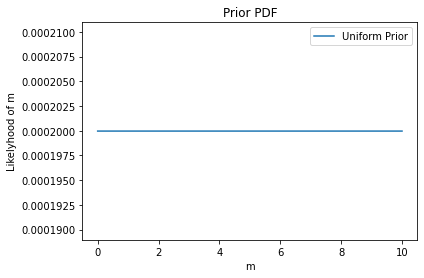

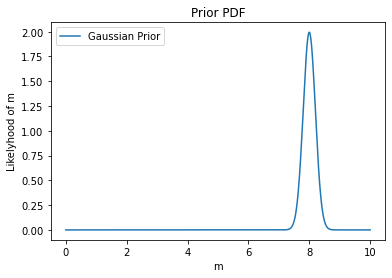

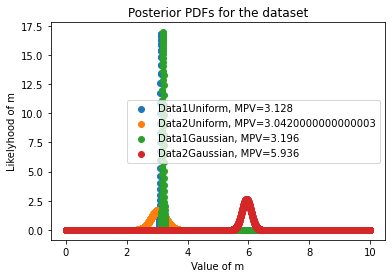

In [225]:
plt.plot(mtest, UniformPrior(mtest), linestyle='-', label='Uniform Prior')
plt.legend()
plt.title('Prior PDF')
plt.xlabel('m')
plt.ylabel('Likelyhood of m')
plt.show()
plt.plot(mtest, GaussianPrior(mtest, mean, sigma), linestyle='-', label='Gaussian Prior')
plt.legend()
plt.title('Prior PDF')
plt.xlabel('m')
plt.ylabel('Likelyhood of m')
plt.show()

plt.scatter(mtest, Data1Uniform, label='Data1Uniform, MPV='+str(mtest[np.argmax(Data1Uniform)]))
plt.scatter(mtest, Data2Uniform, label='Data2Uniform, MPV='+str(mtest[np.argmax(Data2Uniform)]))
plt.scatter(mtest, Data1Gaussian, label='Data1Gaussian, MPV='+str(mtest[np.argmax(Data1Gaussian)]))
plt.scatter(mtest, Data2Gaussian, label='Data2Gaussian, MPV='+str(mtest[np.argmax(Data2Gaussian)]))
plt.legend()
plt.title('Posterior PDFs for the dataset')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

In [226]:
#I think Data1 is just too good for it to really move the MPV

Data 1
MPV = 3.128 with 68% confidence at 3.06 and 3.196
MPV_68% = 3.128 +/- 0.068
MPV = 3.128 with 90% confidence at 3.05 and 3.206
MPV_90% = 3.128 +/- 0.078
Data 2
MPV = 3.128 with 68% confidence at 2.594 and 3.49
MPV_68% = 3.128 +/- 0.534
MPV = 3.128 with 90% confidence at 2.446 and 3.638
MPV_90% = 3.128 +/- 0.682


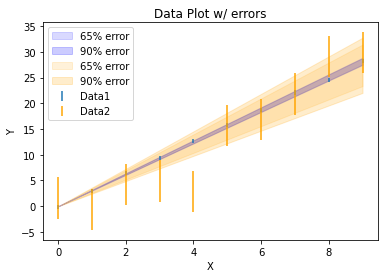

In [227]:
#OK how will we get the 68% and 90% range? 
#Take values around the MPV, integrate, compare, move out a value if less than?
#Seems a little ouch but should work

plt.errorbar(Data1['x'], Data1['y'], yerr=Data1['yerr'], label='Data1', linestyle='')
plt.errorbar(Data2['x'], Data2['y'], yerr=Data2['yerr'], label='Data2', linestyle='', color='orange')

lowerlim=np.argmax(Data1Uniform)
upperlim=np.argmax(Data1Uniform)

print('Data 1')
while -np.trapz(mtest[lowerlim:upperlim], Data1Uniform[lowerlim:upperlim])<=0.68:
    lowerlim -=1
    upperlim +=1
print(f'MPV = {mtest[np.argmax(Data1Uniform)]:.4}' + f' with 68% confidence at {mtest[lowerlim]:.4} and {mtest[upperlim]:.4}')
print(f'MPV_68% = {mtest[np.argmax(Data1Uniform)]:.4} +/- {mtest[np.argmax(Data1Uniform)] - mtest[lowerlim]:.4}')
plt.fill_between(Data1['x'], Data1['x']*mtest[lowerlim], Data1['x']*mtest[upperlim], alpha=0.15, label='65% error', color='blue')
while -np.trapz(mtest[lowerlim:upperlim], Data1Uniform[lowerlim:upperlim])<=0.90:
    lowerlim -=1
    upperlim +=1
print(f'MPV = {mtest[np.argmax(Data1Uniform)]:.4}' + f' with 90% confidence at {mtest[lowerlim]:.4} and {mtest[upperlim]:.4}')
print(f'MPV_90% = {mtest[np.argmax(Data1Uniform)]:.4} +/- {mtest[np.argmax(Data1Uniform)] - mtest[lowerlim]:.4}')
plt.fill_between(Data1['x'], Data1['x']*mtest[lowerlim], Data1['x']*mtest[upperlim], alpha=0.2, label='90% error', color='blue')

lowerlim=np.argmax(Data2Uniform)
upperlim=np.argmax(Data2Uniform)

print('Data 2')
while -np.trapz(mtest[lowerlim:upperlim], Data2Uniform[lowerlim:upperlim])<=0.68:
    lowerlim -=1
    upperlim +=1
print(f'MPV = {mtest[np.argmax(Data1Uniform)]:.4}' + f' with 68% confidence at {mtest[lowerlim]:.4} and {mtest[upperlim]:.4}')
print(f'MPV_68% = {mtest[np.argmax(Data1Uniform)]:.4} +/- {mtest[np.argmax(Data1Uniform)] - mtest[lowerlim]:.4}')
plt.fill_between(Data2['x'], Data2['x']*mtest[lowerlim], Data2['x']*mtest[upperlim], alpha=0.15, label='65% error', color='orange')
while -np.trapz(mtest[lowerlim:upperlim], Data2Uniform[lowerlim:upperlim])<=0.90:
    lowerlim -=1
    upperlim +=1
print(f'MPV = {mtest[np.argmax(Data1Uniform)]:.4}' + f' with 90% confidence at {mtest[lowerlim]:.4} and {mtest[upperlim]:.4}')
print(f'MPV_90% = {mtest[np.argmax(Data1Uniform)]:.4} +/- {mtest[np.argmax(Data1Uniform)] - mtest[lowerlim]:.4}')
plt.fill_between(Data2['x'], Data2['x']*mtest[lowerlim], Data2['x']*mtest[upperlim], alpha=0.2, label='90% error', color='orange')


plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

#the plot is being extra but I haven't used fill_between before. I've done it horribly but this is cool
#for sure using this in the future. Though I'll need to make that while loop better lol
#Also why are my integrals negative

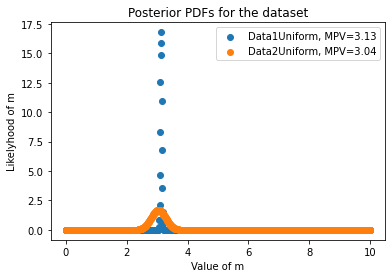

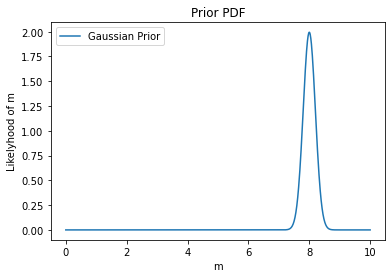

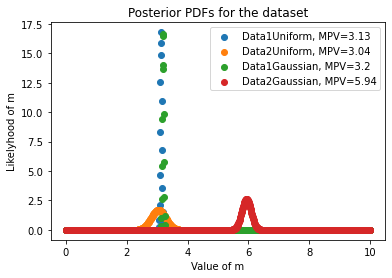

In [203]:
#OK to be as explicit to the problems as possible
#part a.)
plt.scatter(mtest, Data1Uniform, label='Data1Uniform, MPV='+str(mtest[np.argmax(Data1Uniform)]))
plt.scatter(mtest, Data2Uniform, label='Data2Uniform, MPV='+str(mtest[np.argmax(Data2Uniform)]))
plt.legend()
plt.title('Posterior PDFs for the dataset')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()
#Data1 is more precise as visually we see it peaked more. The wider Data2 Posterior indicates there is less reliability
#on the estimator that is mhat. 

#part b.)
#Here's the printout I have. I am using a density of 1001 between 0 and 1 so 0.01 spacing between test values

'''

Data 1
MPV = 3.128 with 68% confidence at 3.06 and 3.196
MPV_68% = 3.128 +/- 0.068
MPV = 3.128 with 90% confidence at 3.05 and 3.206
MPV_90% = 3.128 +/- 0.078
Data 2
MPV = 3.128 with 68% confidence at 2.594 and 3.49
MPV_68% = 3.128 +/- 0.534
MPV = 3.128 with 90% confidence at 2.446 and 3.638
MPV_90% = 3.128 +/- 0.682
'''

#part c.)
# mean=8 #Values for the gaussian prior
# sigma=0.2 #chosen to be really bad
plt.plot(mtest, GaussianPrior(mtest, mean, sigma), linestyle='-', label='Gaussian Prior')
plt.legend()
plt.title('Prior PDF')
plt.xlabel('m')
plt.ylabel('Likelyhood of m')
plt.show()

plt.scatter(mtest, Data1Uniform, label='Data1Uniform, MPV='+str(mtest[np.argmax(Data1Uniform)]))
plt.scatter(mtest, Data2Uniform, label='Data2Uniform, MPV='+str(mtest[np.argmax(Data2Uniform)]))
plt.scatter(mtest, Data1Gaussian, label='Data1Gaussian, MPV='+str(mtest[np.argmax(Data1Gaussian)]))
plt.scatter(mtest, Data2Gaussian, label='Data2Gaussian, MPV='+str(mtest[np.argmax(Data2Gaussian)]))
plt.legend()
plt.title('Posterior PDFs for the dataset')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

#we see that while Data1 is pretty stuck in place(through the MPV does shift some), the Data2 posterior shifts a lot
#If we had a better prior though the posterior does improve a lot
#well you'd need to recalculate Data1Gaussian and Data2Gaussian but it does shift

Problem 2

Part a.) Consider a Poission Distribution with mean $\lambda$. What is the estimator for the mean of a set of randomly sampled values from this distribution $\hat\lambda$?

I'll keep away from the alligned environment for this so we'll see how this looks

Our PDF is $p(x_i|\lambda) = \frac{\lambda^{x_{i}}}{x_i!}e^{-\lambda}$

The measurements are independent, so we can write the log likelyhood as $ln(\mathcal{L}) = \sum_{i=1}^N x_iln(\lambda)-N\lambda-ln(x_i!)$

To find the best estimate for the mean we find where the derivitive is equal to 0. Taking the derivitive with respect to lambda we find $\frac{d}{d\lambda}ln(\mathcal{L}) = \frac{\sum_{i=1}^N x_i}{\lambda} - N$

$\frac{d}{d\lambda}ln(\mathcal{L}) = 0$ so we can say $\frac{\sum_{i=1}^N x_i}{\lambda} = N$

Solving for $\lambda$ we find $\lambda = \frac{1}{N}\sum_{i=1}^N x_i$

Since this is determined by our data this is $\hat\lambda = \frac{1}{N}\sum_{i=1}^N x_i$ AKA the estimator for the mean is the mean of the values we have observed

==============================================================================

Part b.) What is the bias for the estimator $\hat\lambda$?

The bias is found by $b = \langle \hat\lambda \rangle - \lambda$

The expectation value is $\langle \frac{1}{N}\sum_{i=1}^N x_i \rangle$

We can move the expectation brackets inside the sum. $\frac{1}{N}\sum_{i=1}^N \langle x_i \rangle$

The expectation value of any given measurement should just be $\lambda$ as it is defined to be. Therefore we now have $\langle \hat\lambda \rangle = \frac{1}{N}\sum_{i=1}^N \lambda$

This summation is the sum of N $\lambda$'s, AKA $\sum_{i=1}^N \lambda = N\lambda$

$\langle \hat\lambda \rangle = \frac{N\lambda}{N} = \lambda$

$b = \langle \hat\lambda \rangle - \lambda$ we now know the expectation value of $\hat\lambda$ is $\lambda$, so the bias will equal 0

$b = \lambda - \lambda = 0$



==============================================================================

Part c.) What is the MSE of the estimator?

MSE = Var($\hat\lambda$)+$b^2$

We know b=0 so the second term will not factor in at all. We need to find the variance of our estimator.

$Var(\hat\lambda) = Var(\frac{1}{N}\sum_{i=1}^N x_i)$ 

We showed in a previous homework (HW 2 problem 2) that Var(ax+b) = $a^2$Var(x). We can use that to pull out the constant

$Var(\frac{1}{N}\sum_{i=1}^N x_i) = \frac{1}{N^2}Var(\sum_{i=1}^N x_i)$

We move the Var inside the sum $\frac{1}{N^2}Var(\sum_{i=1}^N x_i) = \frac{1}{N^2}\sum_{i=1}^N Var(x_i)$

The variance of a poission distribution is also defined as $\lambda$ by definition. Mean and Variance are the same

$\frac{1}{N^2}\sum_{i=1}^N Var(x_i) = \frac{N\lambda}{N^2} = \frac{\lambda}{N} = Var(\hat\lambda)$

Therefore MSE = $\frac{\lambda}{N}$. Which tracks as $\sigma_{\hat\lambda} = \sqrt{\frac{\lambda}{N}}$ and I think we've seen this in class. At least the sqrt(N) part showing how our variance on the estimator grows smaller as we get more samples

Problem 3.)

part a.) 

I found in Lecture 5 notes that the expectation value and variance for a $\chi^2_n$ distribution are n and 2n, respectively. This will be used as the values for the hint given in the problem(well n-1 and 2n-2 more accurately)

$\frac{(N-1)s^2}{\sigma^2} = \chi^2_{N-1}$ We can use this and find the expectation value of both sides

$\langle \frac{(N-1)s^2}{\sigma^2} \rangle = \langle \chi^2_{N-1} \rangle $ We sub in the expectation value for $\chi^2$

$\langle \frac{(N-1)s^2}{\sigma^2} \rangle = N-1 $ Factor out constants on the left side from the expectation value

$\frac{(N-1)}{\sigma^2} \langle s^2 \rangle = N-1 $ cancel out the N-1 terms

$\frac{\langle s^2 \rangle}{\sigma^2}  = 1 $ Rearrange and we find that

$\langle s^2 \rangle  = \sigma^2 $ Since they are directly equal and we do not have any additional factors, the bias term is 0. $s^2$ is an unbised estimator for $\sigma^2$

==========================================================================================

We can also show how the variance looks. We start the same

$\frac{(N-1)s^2}{\sigma^2} = \chi^2_{N-1}$ We find the variance of both sides

$Var(\frac{(N-1)s^2}{\sigma^2}) = Var(\chi^2_{N-1})$ We know the variance of the chi^2 distribution

$Var(\frac{(N-1)s^2}{\sigma^2}) = 2(N-1)$ We can pull out factors using $Var(ax+b) = a^2Var(x)$

$(\frac{(N-1)}{\sigma^2})^2Var(s^2) = 2(N-1)$ Expand

$(\frac{(N-1)(N-1)}{\sigma^4})Var(s^2) = 2(N-1)$ Divide by 2(N-1)

$\frac{(N-1)}{2\sigma^4}Var(s^2) = 1$ Rearrange to find

$Var(s^2) = \frac{2\sigma^4}{(N-1)}$ Since we know $\sigma = 1$, we can say

$Var(s^2) = \frac{2}{(N-1)}$

part b.) 

The only change we make is we find $s^2_k$ instead of $s^2_1$

We know that $\langle s^2 \rangle  = \sigma^2 $

Since $\langle s^2 \rangle = \langle \frac{1}{1-N}\sum_{i=1}^N(x_i-\hat x)^2$, we can rearrange and use some expectation value properties to show $\langle \sum_{i=1}^N(x_i-\hat x)^2 \rangle = (N-1)\sigma^2$

Now we return to the $s^2_k$ formula. $\langle s^2_k \rangle = \langle \frac{1}{N+k}\sum_{i=1}^N(x_i-\hat x)^2 \rangle$

This equals $\langle s^2_k \rangle = \frac{1}{N+k}\langle \sum_{i=1}^N(x_i-\hat x)^2 \rangle = \frac{1}{N+k}(N-1)\sigma^2$

$\langle s^2_k \rangle = \sigma^2\frac{N-1}{N+k}$

This is only unbiased if $\frac{N-1}{N+k} = 1$, which is the case for k=-1. This is the case we solved for previously

The bias is just $b = \langle s^2_k \rangle - \sigma^2$

$b=\sigma^2\frac{N-1}{N+k} - \sigma^2$

$b=\sigma^2(\frac{N-1}{N+k} - 1)$

Since $\sigma = 1$ this simplifies to $b=\frac{N-1}{N+k} - 1$

MSE is calculated as the variance plus bias^2, so we need the variance

$Var(s^2_k) = Var(\frac{1}{1-N}\sum_{i=1}^N(x_i-\hat x)^2)$

We move constants out $Var(s^2_k) = $\frac{1}{1-N}Var(\sum_{i=1}^N(x_i-\hat x)^2)

OK so this looks familiar to $Var(s^2) = \frac{2}{(N-1)}$. We need to account for that $\sigma^2\frac{1}{N+k}$ term, which will be the constant we pull out from the Variance. Which means we will need to square this term.

$Var(s^2_k) = 2(N-1) \frac{\sigma^2}{N+k}^2 = \frac{2\sigma^4(N-1)}{(N+k)^2}$

Since $\sigma = 1$ this turns to $Var(s^2_k) = \frac{2(N-1)}{(N+k)^2}$ which looks right

MSE = Var + b^2

$MSE = (\frac{N-1}{N+k} - 1)^2 + \frac{2(N-1)}{(N+k)^2}$

$MSE = (\frac{(N-1)^2}{(N+k)^2} -2\frac{N-1}{N+k} + 1) + 2\frac{(N-1)}{(N+k)^2}$

This can simplify to $MSE = \frac{(k+1)^2+2(N-1)}{(N+k)^2}$ (thanks wolfram)

Now we can show that the derivitive of this function is minimized at k=1. We take the derivitive $\frac{d}{dk}\frac{(k+1)^2+2(N-1)}{(N+k)^2} = \frac{(2 (-1 + k) (-1 + N))}{(k + N)^3}$

We find what values we set k to for the derivitive to be 0. $0 = \frac{(2 (-1 + k) (-1 + N))}{(k + N)^3}$

This is only true when the numerator is 0, and we also make sure that the denominator is not 0 simultaneously. The numerator is 0 when k=1

The denominator is not also 0 when k=1 since N will be a positive number, so the denominator will always be greater than 0. Therefore we show the MSE is minimized when k=1 despite the fact the bias is non-0 for k=1